In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#**Step 1: Data Collection**

In [3]:
path=os.path.join('/content/drive/MyDrive/Colab Notebooks/NLP Project/Reviews.csv')
reviews = pd.read_csv(path)
reviews.head(5)

,id,Review ID,Item ID,Shop ID,Comment,Rating Star,Author Username,Images,Submit Time,Like Count,Product Quality,Seller Service,Delivery Service,Class
0,9.337460e+09,9.337460e+09,20415254195,414659819,Material:Great!\nFunctionality:Great too!\n\nT...,5,vinibalan,https://down-id.img.susercontent.com/file/my-1...,21/8/2022 8:06,45,5,Not Available,Not Available,positive
1,1.561530e+10,1.561530e+10,20415254195,414659819,Functionality:functioning well and great size ...,5,yana4eva,https://down-id.img.susercontent.com/file/my-1...,24/6/2024 13:43,12,5,5,5,positive
2,7.557180e+10,7.557180e+10,20415254195,414659819,"Performance:Struktur yg kukuh, tegap dan kuat....",5,n*****0,https://down-id.img.susercontent.com/file/my-1...,8/10/2025 10:17,2,5,5,5,positive
3,7.700363e+10,7.700363e+10,20415254195,414659819,Performance:Good\n\nMeja besar. Sesuai sangat ...,5,azila_aria,https://down-id.img.susercontent.com/file/my-1...,19/10/2025 9:27,1,5,5,5,positive
4,9.428977e+10,9.428977e+10,20415254195,414659819,Material:High-quality wooden\nFunctionality:Si...,5,facrulalif,https://down-id.img.susercontent.com/file/my-1...,2/4/2026 13:43,Not Available,5,5,5,positive


In [4]:
reviews = reviews[['Comment', 'Class']]
reviews.head()

,Comment,Class
0,Material:Great!\nFunctionality:Great too!\n\nT...,positive
1,Functionality:functioning well and great size ...,positive
2,"Performance:Struktur yg kukuh, tegap dan kuat....",positive
3,Performance:Good\n\nMeja besar. Sesuai sangat ...,positive
4,Material:High-quality wooden\nFunctionality:Si...,positive


# **Step 2: Data Pre-processing (Lab 4(tokenization, lemmatization, stopword removal) + 9(pos-tagging))**

**1. Remove Invalid Entries (Data Cleaning Step)**

In [5]:
# Remove duplicated comments
reviews = reviews.drop_duplicates(subset=["Comment"])

# Remove rows where Comment is missing
reviews = reviews.dropna(subset=['Comment'])

# Check remaining missing values
reviews.isnull().sum()

# Remove "Not Available" reviews
reviews = reviews[reviews['Comment'].str.lower() != 'not available']

# Show total number of reviews per class
class_counts = reviews['Class'].value_counts()

print("Class distribution:")
print(class_counts)

Class distribution:
Class
positive    150
negative    150
neutral     120
Name: count, dtype: int64


**2. Translation (Malay and Chinese to English)**

In [6]:
!pip install deep-translator

In [7]:
from deep_translator import GoogleTranslator

def translate_to_english(text):
    try:
        if any('\u4e00' <= char <= '\u9fff' for char in text):
            return GoogleTranslator(source='zh-TW', target='en').translate(text)

        return GoogleTranslator(source='auto', target='en').translate(text)

    except:
        return text

In [8]:
reviews['translated'] = reviews['Comment'].apply(translate_to_english)
reviews[['Comment', 'translated']].head()

,Comment,translated
0,Material:Great!\nFunctionality:Great too!\n\nT...,Material:Great!\nFunctionality:Great too!\n\nT...
1,Functionality:functioning well and great size ...,Functionality:functioning well and great size ...
2,"Performance:Struktur yg kukuh, tegap dan kuat....","Performance: Strong, sturdy and strong structu..."
3,Performance:Good\n\nMeja besar. Sesuai sangat ...,Performance: Good\n\nBig table. Very suitable ...
4,Material:High-quality wooden\nFunctionality:Si...,Material: High-quality wood\nFunctionality: Ke...


**3. Text Cleaning**

In [9]:
import re

def clean_text(text):

    text = text.lower()

    # Fix encoding issues
    text = text.replace("’", "'")
    text = text.replace("‘", "'")
    text = text.replace("“", '"')
    text = text.replace("”", '"')

    # Remove URLs
    text = re.sub(r'http\S+', '', text)

    # Remove HTML
    text = re.sub(r'<.*?>', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Rreduce repeated characters (spam control)
    text = re.sub(r'(.)\1{2,}', r'\1', text)

    # Normalize laughter patterns
    text = re.sub(r'ha{2,}', 'haha', text)

    # Remove punctuation but KEEP emojis
    text = re.sub(r'[!"#$%&\'()*+,\-./:;<=>?@[\\\]^_`{|}~]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [10]:
reviews['cleaned'] = reviews['translated'].apply(clean_text)
reviews[['translated', 'cleaned']].head()

,translated,cleaned
0,Material:Great!\nFunctionality:Great too!\n\nT...,material great functionality great too this ha...
1,Functionality:functioning well and great size ...,functionality functioning well and great size ...
2,"Performance: Strong, sturdy and strong structu...",performance strong sturdy and strong structure...
3,Performance: Good\n\nBig table. Very suitable ...,performance good big table very suitable for s...
4,Material: High-quality wood\nFunctionality: Ke...,material high quality wood functionality keep ...


**4. Tokenization**

In [11]:
import nltk
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from nltk.corpus import wordnet

def tokenize_text(text):
    return word_tokenize(text)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [12]:
reviews['tokens_raw'] = reviews['cleaned'].apply(tokenize_text)
reviews[['cleaned', 'tokens_raw']].head()

,cleaned,tokens_raw
0,material great functionality great too this ha...,"[material, great, functionality, great, too, t..."
1,functionality functioning well and great size ...,"[functionality, functioning, well, and, great,..."
2,performance strong sturdy and strong structure...,"[performance, strong, sturdy, and, strong, str..."
3,performance good big table very suitable for s...,"[performance, good, big, table, very, suitable..."
4,material high quality wood functionality keep ...,"[material, high, quality, wood, functionality,..."


In [13]:
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [14]:
def get_wordnet_pos(word):
    tag = pos_tag([word])[0][1][0].upper()

    tag_dict = {
        "J": wordnet.ADJ,
        "N": wordnet.NOUN,
        "V": wordnet.VERB,
        "R": wordnet.ADV
    }

    return tag_dict.get(tag, wordnet.NOUN)

**5. Lemmatization**

In [15]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word, get_wordnet_pos(word)) for word in tokens]

In [16]:
reviews['lemmatized_tokens'] = reviews['tokens_raw'].apply(lemmatize_tokens)
reviews[['tokens_raw', 'lemmatized_tokens']].head()

,tokens_raw,lemmatized_tokens
0,"[material, great, functionality, great, too, t...","[material, great, functionality, great, too, t..."
1,"[functionality, functioning, well, and, great,...","[functionality, function, well, and, great, si..."
2,"[performance, strong, sturdy, and, strong, str...","[performance, strong, sturdy, and, strong, str..."
3,"[performance, good, big, table, very, suitable...","[performance, good, big, table, very, suitable..."
4,"[material, high, quality, wood, functionality,...","[material, high, quality, wood, functionality,..."


**6. Stop word removal**

In [17]:
nltk.download('stopwords')

from nltk.corpus import stopwords

# English stopword list
stoplist = set(stopwords.words('english'))
# Remain the negation as it plays different meaning if applied
stoplist -= {"not", "no", "nor"}

# Show stopwords
print(stoplist)

{'won', 'doesn', 'down', "didn't", 'very', 'don', 'during', 'them', 'themselves', "shouldn't", 'until', 'a', 'or', 'when', 'at', 'does', "mustn't", 'but', 'whom', 'above', 'i', 'aren', 'own', 'after', 'that', "isn't", 'once', 'should', "wouldn't", "needn't", 'while', 'your', 'be', 'its', 'my', 'which', "you'll", 'having', 'him', 'mustn', "we'd", 'with', "it'd", "we'll", 'into', 'where', 'will', "hasn't", "mightn't", "it'll", "they're", 'y', "couldn't", 'any', 'do', "i'm", 'some', 'shan', 'more', 're', 'were', 'here', 'about', 'than', 'needn', 'both', 'yourself', "we're", 'who', 'now', 'hasn', 'was', "you'd", 'by', 'been', "i'd", 'an', 'then', "wasn't", 'the', 'weren', "aren't", 'from', 'are', 'these', 'each', 'over', 'itself', "we've", 'myself', 'm', 'has', 'hadn', "should've", "don't", 'why', 'only', 'his', 'hers', 'most', 'so', 'is', 'our', 'o', "she'll", 'just', 'he', 'of', 'mightn', 'himself', "haven't", 'out', 'their', 'off', 's', "she's", 'being', 'yours', "they'll", 'can', 'agai

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [18]:
def remove_stopwords(tokens):
    return [word for word in tokens if word not in stoplist]

In [19]:
reviews['tokens_nostop'] = reviews['lemmatized_tokens'].apply(remove_stopwords)

In [20]:
reviews[['Comment', 'Class', 'translated', 'cleaned', 'tokens_raw', 'lemmatized_tokens', 'tokens_nostop']]

,Comment,Class,translated,cleaned,tokens_raw,lemmatized_tokens,tokens_nostop
0,Material:Great!\nFunctionality:Great too!\n\nT...,positive,Material:Great!\nFunctionality:Great too!\n\nT...,material great functionality great too this ha...,"[material, great, functionality, great, too, t...","[material, great, functionality, great, too, t...","[material, great, functionality, great, favour..."
1,Functionality:functioning well and great size ...,positive,Functionality:functioning well and great size ...,functionality functioning well and great size ...,"[functionality, functioning, well, and, great,...","[functionality, function, well, and, great, si...","[functionality, function, well, great, size, s..."
2,"Performance:Struktur yg kukuh, tegap dan kuat....",positive,"Performance: Strong, sturdy and strong structu...",performance strong sturdy and strong structure...,"[performance, strong, sturdy, and, strong, str...","[performance, strong, sturdy, and, strong, str...","[performance, strong, sturdy, strong, structur..."
3,Performance:Good\n\nMeja besar. Sesuai sangat ...,positive,Performance: Good\n\nBig table. Very suitable ...,performance good big table very suitable for s...,"[performance, good, big, table, very, suitable...","[performance, good, big, table, very, suitable...","[performance, good, big, table, suitable, stud..."
4,Material:High-quality wooden\nFunctionality:Si...,positive,Material: High-quality wood\nFunctionality: Ke...,material high quality wood functionality keep ...,"[material, high, quality, wood, functionality,...","[material, high, quality, wood, functionality,...","[material, high, quality, wood, functionality,..."
...,...,...,...,...,...,...,...
415,"Material:Not bad, value for the money\n\nToo l...",neutral,"Material:Not bad, value for the money\n\nToo l...",material not bad value for the money too lite ...,"[material, not, bad, value, for, the, money, t...","[material, not, bad, value, for, the, money, t...","[material, not, bad, value, money, lite, weight]"
416,Effectiveness:Fair\nMaterial:Fair\n\nHeat up q...,neutral,Effectiveness:Fair\nMaterial:Fair\n\nHeat up q...,effectiveness fair material fair heat up quick...,"[effectiveness, fair, material, fair, heat, up...","[effectiveness, fair, material, fair, heat, up...","[effectiveness, fair, material, fair, heat, qu..."
417,"Effectiveness:not really effective lahh, have ...",neutral,"Effectiveness:not really effective lahh, have ...",effectiveness not really effective lahh have t...,"[effectiveness, not, really, effective, lahh, ...","[effectiveness, not, really, effective, lahh, ...","[effectiveness, not, really, effective, lahh, ..."
418,Size okay but the straightener not so hot..hop...,neutral,Size okay but the straightener not so hot..hop...,size okay but the straightener not so hot hope...,"[size, okay, but, the, straightener, not, so, ...","[size, okay, but, the, straightener, not, so, ...","[size, okay, straightener, not, hot, hope, fut..."


**7. Export Final CSV**

In [21]:
# Convert token list into string (CSV-friendly format)
reviews['final_text'] = reviews['tokens_nostop'].apply(lambda x: ' '.join(x))

# Keep only relevant columns
final_df = reviews[['final_text', 'Class']].rename(columns={
    'final_text': 'processed_text'
})

# Save to CSV
final_df.to_csv('Reviews_Final.csv', index=False, encoding='utf-8-sig')
print("CSV exported successfully!")

CSV exported successfully!


#**Step 3: Knowledge Representation**

### 3.1 Load the Pre-processed Data
We load the cleaned corpus exported at the end of Step 2 (`Reviews_Final.csv`).

In [22]:
# 3.1 Load the pre-processed data (output of Step 2)
import pandas as pd
from sklearn.model_selection import train_test_split

# The pre-processed corpus was exported as Reviews_Final.csv at the end of Step 2.
try:
    kr_df = pd.read_csv('Reviews_Final.csv')
except FileNotFoundError:
    kr_df = final_df.copy()            # fallback to the in-memory dataframe

# A few reviews may be empty after cleaning / stop-word removal -> drop them
kr_df['processed_text'] = kr_df['processed_text'].fillna('').str.strip()
kr_df = kr_df[kr_df['processed_text'] != ''].reset_index(drop=True)

# Use the already-created preprocessing columns so every representation/model
# receives exactly the same train, validation, and test rows.
model_df = reviews[['translated', 'final_text', 'tokens_nostop', 'Class']].copy()
model_df = model_df.rename(columns={'final_text': 'processed_text'})
model_df = model_df[model_df['processed_text'].fillna('').str.strip() != ''].reset_index(drop=True)

train_df, temporary_df = train_test_split(
    model_df,
    test_size=0.30,
    random_state=42,
    stratify=model_df['Class']
)
validation_df, test_df = train_test_split(
    temporary_df,
    test_size=0.50,
    random_state=42,
    stratify=temporary_df['Class']
)

train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# Rebuild kr_df in the same row order used by the combined feature matrices below.
kr_df = pd.concat([train_df, validation_df, test_df], ignore_index=True)
kr_df['tokens'] = kr_df['tokens_nostop']

print('Training documents  :', len(train_df))
print('Validation documents:', len(validation_df))
print('Testing documents   :', len(test_df))
print('\nClass distribution:')
print(kr_df['Class'].value_counts())
kr_df.head()

Training documents  : 294
Validation documents: 63
Testing documents   : 63

Class distribution:
Class
negative    150
positive    150
neutral     120
Name: count, dtype: int64


,translated,processed_text,tokens_nostop,Class,tokens
0,What is this? Free item? I did not received pu...,free item not receive pun cheat buyer la,"[free, item, not, receive, pun, cheat, buyer, la]",negative,"[free, item, not, receive, pun, cheat, buyer, la]"
1,"Material:Wood\nFunctionality:Nice wood finish,...",material wood functionality nice wood finish s...,"[material, wood, functionality, nice, wood, fi...",positive,"[material, wood, functionality, nice, wood, fi..."
2,Broken,broken,[broken],negative,[broken]
3,There are 3 seeds missing,seed miss,"[seed, miss]",negative,"[seed, miss]"
4,Performance:O,performance,[performance],negative,[performance]


### 3.2 Approach 1 — TF-IDF (Term Frequency – Inverse Document Frequency)

TF-IDF scores how important a word is to a document within the corpus. It combines two parts (as derived in Lab 6):

- **Term Frequency** — how often a word *w* appears in a document:
  $$TF(w) = \log_{10}\big(\text{count}(w) + 1\big)$$
- **Inverse Document Frequency** — how rare the word is across all *N* documents:
  $$IDF(w) = \log_{10}\!\left(\frac{N}{df(w)}\right)$$
- **TF-IDF** is the product: $TF(w) \times IDF(w)$

Common words (e.g. *the*, *and*) get low scores, while distinctive sentiment-bearing words (e.g. *great*, *broken*) get high scores. We apply scikit-learn's `TfidfVectorizer` to the training data only. The fitted vectorizer was then used to transform the validation and testing data

In [23]:
# 3.2 TF-IDF representation (scikit-learn)
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy.sparse as sp

# unigrams + bigrams; vocabulary and IDF are learned from training data only
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_train_tf = tfidf_vectorizer.fit_transform(train_df['processed_text'])
X_val_tf = tfidf_vectorizer.transform(validation_df['processed_text'])
X_test_tf = tfidf_vectorizer.transform(test_df['processed_text'])

# Combined matrix is used only for representation display/export.
X_tfidf = sp.vstack([X_train_tf, X_val_tf, X_test_tf]).tocsr()
feature_names = tfidf_vectorizer.get_feature_names_out()

print('Training TF-IDF shape  :', X_train_tf.shape)
print('Validation TF-IDF shape:', X_val_tf.shape)
print('Testing TF-IDF shape   :', X_test_tf.shape)
print('Vocabulary size        :', len(feature_names))

pd.DataFrame(X_train_tf[:100].toarray(), columns=feature_names).iloc[:, :10]

Training TF-IDF shape  : (294, 792)
Validation TF-IDF shape: (63, 792)
Testing TF-IDF shape   : (63, 792)
Vocabulary size        : 792


,ab,able,absorption,acceptable,accord,accord price,adjust,adjustable,advertised,affordable
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
95,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
96,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
97,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
98,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**Most important terms.** We rank terms by their average TF-IDF weight across the corpus, and also inspect the most representative terms per sentiment class.

In [24]:
import numpy as np

# Mean TF-IDF weight of each term across all reviews
mean_tfidf = np.asarray(X_tfidf.mean(axis=0)).ravel()
top_terms = (pd.DataFrame({'term': feature_names, 'mean_tfidf': mean_tfidf})
               .sort_values('mean_tfidf', ascending=False)
               .head(20).reset_index(drop=True))
top_terms

,term,mean_tfidf
0,not,0.054206
1,good,0.053085
2,quality,0.048631
3,ok,0.041583
4,performance,0.037222
5,seller,0.033861
6,material,0.033246
7,price,0.030473
8,durability,0.027636
9,use,0.027454


In [25]:
# Most representative terms per sentiment class
def top_terms_for_class(label, n=10):
    rows = np.where(kr_df['Class'].values == label)[0]
    mean_w = np.asarray(X_tfidf[rows].mean(axis=0)).ravel()
    idx = mean_w.argsort()[::-1][:n]
    return [feature_names[i] for i in idx]

for label in ['positive', 'neutral', 'negative']:
    if label in kr_df['Class'].unique():
        print(f'{label:9}:', ', '.join(top_terms_for_class(label)))

positive : good, beautiful, quality, seller, fast, durability, table, material, delivery, price
neutral  : ok, not, okay, quality, performance, price, good, sound, quality ok, not bad
negative : not, bad, performance, ipad, item, even, receive, broken, charge, seller


In [ ]:
# Visualise the top TF-IDF terms
import matplotlib.pyplot as plt

top15 = top_terms.head(15).iloc[::-1]   # reverse so the largest is on top
plt.figure(figsize=(8, 6))
plt.barh(top15['term'], top15['mean_tfidf'], color='#4C72B0')
plt.xlabel('Mean TF-IDF weight')
plt.title('Top 15 Terms by Average TF-IDF Weight')
plt.tight_layout()
plt.show()

### 3.3 Approach 2 — Word2Vec (Word Embeddings)

Word2Vec learns a dense vector for every word so that words used in **similar contexts** get **similar vectors**. Unlike TF-IDF, it captures *semantic meaning*, allowing vector math to find related words (cf. Lab 6).

We train Word2Vec on our own review corpus, then create one fixed-length vector per review by **averaging** its word embeddings (mean pooling).

In [ ]:
# 3.3 Word2Vec representation (gensim)
try:
    from gensim.models import Word2Vec
except Exception:
    !pip install -q "gensim>=4.3.2"
    from gensim.models import Word2Vec

w2v_model = Word2Vec(
    sentences=train_df['tokens_nostop'].tolist(),
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    epochs=100,
    seed=42
)

print('Word2Vec vocabulary size :', len(w2v_model.wv))
print('Embedding dimension      :', w2v_model.vector_size)
if 'good' in w2v_model.wv:
    print('\nVector for "good" (first 10 of 100 dims):')
    print(np.round(w2v_model.wv['good'][:10], 3))

In [ ]:
# Semantically similar words (vector math on the embeddings) -- cf. Lab 6
for word in ['good', 'quality', 'price', 'delivery', 'bad']:
    if word in w2v_model.wv:
        print(f'\nWords similar to "{word}":')
        for w, score in w2v_model.wv.most_similar(word, topn=5):
            print(f'   {w:15} {score:.3f}')

**Document embeddings.** A review has a variable number of words, but models need fixed-length input. We average the Word2Vec vectors of all words in a review to obtain one 100-dimensional vector per review.

In [ ]:
# Document embedding = mean of the word vectors in each review
def document_vector(tokens, model):
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    if not vecs:
        return np.zeros(model.vector_size, dtype=np.float32)
    return np.mean(vecs, axis=0)

X_train_wv = np.vstack([
    document_vector(tokens, w2v_model) for tokens in train_df['tokens_nostop']
])
X_val_wv = np.vstack([
    document_vector(tokens, w2v_model) for tokens in validation_df['tokens_nostop']
])
X_test_wv = np.vstack([
    document_vector(tokens, w2v_model) for tokens in test_df['tokens_nostop']
])

# Combined matrix is used only for representation display/export.
X_w2v = np.vstack([X_train_wv, X_val_wv, X_test_wv])
print('Word2Vec document-embedding matrix shape:', X_w2v.shape,
      '(documents x', w2v_model.vector_size, 'dims)')

w2v_doc_df = pd.DataFrame(X_w2v, columns=[f'w2v_{i}' for i in range(X_w2v.shape[1])])
w2v_doc_df.head()

**Visualising the embeddings.** We project the 100-dimensional vectors of the most frequent words down to 2-D with PCA. Words with related meaning/sentiment tend to cluster together.

In [ ]:
# 2-D visualisation of the word embeddings (PCA)
from sklearn.decomposition import PCA

words = w2v_model.wv.index_to_key[:30]          # 30 most frequent words
vecs = w2v_model.wv[words]
coords = PCA(n_components=2, random_state=42).fit_transform(vecs)

plt.figure(figsize=(10, 7))
plt.scatter(coords[:, 0], coords[:, 1], color='#55A868')
for (x, y), w in zip(coords, words):
    plt.annotate(w, (x, y), fontsize=9, xytext=(3, 3), textcoords='offset points')
plt.title('Word2Vec Embeddings of Top 30 Words (PCA projection)')
plt.xlabel('PC 1'); plt.ylabel('PC 2')
plt.tight_layout()
plt.show()

### 3.4 Saving the Knowledge Representation

We persist every representation in an *appropriate format* (as required by the rubric) so Step 4 can load them directly:

- `tfidf_features.csv` — TF-IDF matrix with labels (human-readable CSV)
- `tfidf_matrix.npz` — compact sparse TF-IDF matrix
- `tfidf_vectorizer.pkl` — the fitted vectorizer (to transform new reviews at deployment)
- `word2vec.model` — the trained Word2Vec model
- `w2v_doc_vectors.npy` — document-embedding matrix
- `knowledge_representation.h5` — a single HDF5 store bundling everything

In [ ]:
# 3.4 Save the knowledge representations in appropriate formats
import os, joblib
import scipy.sparse as sp

KR_DIR = '/content/drive/MyDrive/Colab Notebooks/NLP Project/knowledge_representation'
os.makedirs(KR_DIR, exist_ok=True)

# 1) TF-IDF features as CSV (human-readable) with the Class label
tfidf_full = pd.DataFrame(X_tfidf.toarray(), columns=feature_names)
tfidf_full['Class'] = kr_df['Class'].values
tfidf_full.to_csv(os.path.join(KR_DIR, 'tfidf_features.csv'), index=False)

# 2) TF-IDF sparse matrix as .npz (compact, efficient for training)
sp.save_npz(os.path.join(KR_DIR, 'tfidf_matrix.npz'), X_tfidf)

# 3) Fitted TF-IDF vectorizer (reused to transform new text at deployment)
joblib.dump(tfidf_vectorizer, os.path.join(KR_DIR, 'tfidf_vectorizer.pkl'))

# 4) Word2Vec model + the document-embedding matrix
w2v_model.save(os.path.join(KR_DIR, 'word2vec.model'))
np.save(os.path.join(KR_DIR, 'w2v_doc_vectors.npy'), X_w2v)

# 5) Bonus: bundle everything into one HDF5 store (rubric example format)
try:
    import tables  # HDF5 engine for pandas
except Exception:
    !pip install -q tables
try:
    h5_path = os.path.join(KR_DIR, 'knowledge_representation.h5')
    with pd.HDFStore(h5_path, mode='w') as store:
        store.put('tfidf', tfidf_full)
        store.put('w2v_doc', pd.concat([w2v_doc_df, kr_df[['Class']]], axis=1))
        store.put('labels', kr_df[['processed_text', 'Class']])
    print('HDF5 store written :', h5_path)
except Exception as e:
    print('HDF5 export skipped (optional):', e)

print('\nSaved knowledge-representation files to:')
for fn in sorted(os.listdir(KR_DIR)):
    print('  -', fn)

### Summary

Both representations are now ready as inputs to **Step 4: Model Training**:

- **TF-IDF** &rarr; sparse matrix `X_tfidf` (shape: documents &times; vocabulary)
- **Word2Vec** &rarr; dense matrix `X_w2v` (shape: documents &times; 100)
- **Labels** &rarr; `kr_df['Class']`

In the next step we train and compare sentiment-classification models on these feature sets.

#**Step 4: Model Training**

## Data Preparation & Splitting

In [34]:
import joblib
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(kr_df['Class'])

y_train = le.transform(train_df['Class'])
y_val = le.transform(validation_df['Class'])
y_test = le.transform(test_df['Class'])

joblib.dump(le, os.path.join(KR_DIR, 'label_encoder.pkl'))

print('TF-IDF Train:', X_train_tf.shape)
print('TF-IDF Validation:', X_val_tf.shape)
print('TF-IDF Test:', X_test_tf.shape)
print('Word2Vec Train:', X_train_wv.shape)
print('Word2Vec Validation:', X_val_wv.shape)
print('Word2Vec Test:', X_test_wv.shape)

TF-IDF Train: (294, 793)
TF-IDF Validation: (63, 793)
TF-IDF Test: (63, 793)
Word2Vec Train: (294, 100)
Word2Vec Validation: (63, 100)
Word2Vec Test: (63, 100)


### Naives Bayes (TF-IDF)

,Alpha,Train Accuracy,Validation Accuracy,Validation Macro F1
0,0.01,0.989796,0.857143,0.855779
1,0.10,0.986395,0.857143,0.855779
2,0.50,0.982993,0.857143,0.858258
3,1.00,0.976190,0.825397,0.825042
4,2.00,0.952381,0.793651,0.788762
5,5.00,0.874150,0.793651,0.787179


Best alpha: 0.5
Best Validation Macro F1: 0.8582578397212544

--- TF-IDF Multinomial Naive Bayes ---
Test Accuracy: 0.8095238095238095
Test Macro F1: 0.7980406212664276

Prediction distribution:
[22 13 28]

True distribution:
[23 18 22]

Classification Report:
              precision    recall  f1-score   support

    negative       0.86      0.83      0.84        23
     neutral       0.85      0.61      0.71        18
    positive       0.75      0.95      0.84        22

    accuracy                           0.81        63
   macro avg       0.82      0.80      0.80        63
weighted avg       0.82      0.81      0.80        63



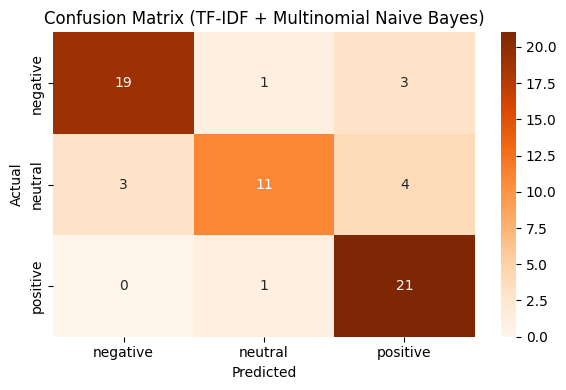

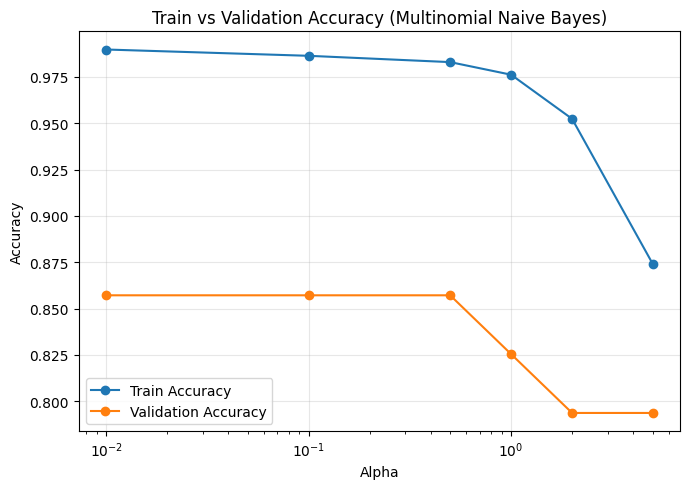

Naive Bayes model saved successfully.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

# -------------------------------------------------
# 1. Select alpha using validation data
# -------------------------------------------------

alpha_values = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]

train_accuracy = []
validation_accuracy = []
validation_macro_f1 = []

for alpha in alpha_values:

    model = MultinomialNB(alpha=alpha)
    model.fit(X_train_tf, y_train)

    train_prediction = model.predict(X_train_tf)
    validation_prediction = model.predict(X_val_tf)

    train_accuracy.append(
        accuracy_score(y_train, train_prediction)
    )

    validation_accuracy.append(
        accuracy_score(y_val, validation_prediction)
    )

    validation_macro_f1.append(
        f1_score(
            y_val,
            validation_prediction,
            average="macro"
        )
    )


# Show validation results
nb_validation_results = pd.DataFrame({
    "Alpha": alpha_values,
    "Train Accuracy": train_accuracy,
    "Validation Accuracy": validation_accuracy,
    "Validation Macro F1": validation_macro_f1
})

display(nb_validation_results)


# Select alpha using validation Macro F1
best_index = np.argmax(validation_macro_f1)
best_alpha = alpha_values[best_index]

print("Best alpha:", best_alpha)
print(
    "Best Validation Macro F1:",
    validation_macro_f1[best_index]
)


# -------------------------------------------------
# 2. Train the selected Naive Bayes model
# -------------------------------------------------

nb_tf = MultinomialNB(alpha=best_alpha)
nb_tf.fit(X_train_tf, y_train)


# -------------------------------------------------
# 3. Final prediction on the test set
# -------------------------------------------------

y_pred_nb = nb_tf.predict(X_test_tf)

print("\n--- TF-IDF Multinomial Naive Bayes ---")

print(
    "Test Accuracy:",
    accuracy_score(y_test, y_pred_nb)
)

print(
    "Test Macro F1:",
    f1_score(
        y_test,
        y_pred_nb,
        average="macro"
    )
)

print("\nPrediction distribution:")
print(np.bincount(y_pred_nb))

print("\nTrue distribution:")
print(np.bincount(y_test))

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_nb,
        target_names=le.classes_,
        zero_division=0
    )
)


# -------------------------------------------------
# 4. Confusion matrix
# -------------------------------------------------

plt.figure(figsize=(6, 4))

sns.heatmap(
    confusion_matrix(y_test, y_pred_nb),
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title(
    "Confusion Matrix "
    "(TF-IDF + Multinomial Naive Bayes)"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


# -------------------------------------------------
# 5. Train vs validation graph
# -------------------------------------------------

plt.figure(figsize=(7, 5))

plt.plot(
    alpha_values,
    train_accuracy,
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    alpha_values,
    validation_accuracy,
    marker="o",
    label="Validation Accuracy"
)

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Accuracy")

plt.title(
    "Train vs Validation Accuracy "
    "(Multinomial Naive Bayes)"
)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# -------------------------------------------------
# 6. Save model
# -------------------------------------------------

joblib.dump(
    nb_tf,
    os.path.join(
        KR_DIR,
        "NB_tfidf.pkl"
    )
)

print("Naive Bayes model saved successfully.")

### Logistic Regression (TF-IDF)

--- TF-IDF Logistic Regression ---
Accuracy: 0.7777777777777778
Train accuracy: 0.9863945578231292
Test accuracy: 0.7777777777777778

Prediction distribution: [25 13 25]
True distribution: [23 18 22]

Classification Report:
              precision    recall  f1-score   support

    negative       0.76      0.83      0.79        23
     neutral       0.77      0.56      0.65        18
    positive       0.80      0.91      0.85        22

    accuracy                           0.78        63
   macro avg       0.78      0.76      0.76        63
weighted avg       0.78      0.78      0.77        63



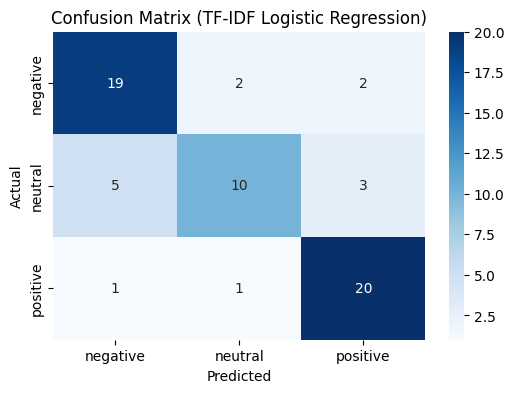

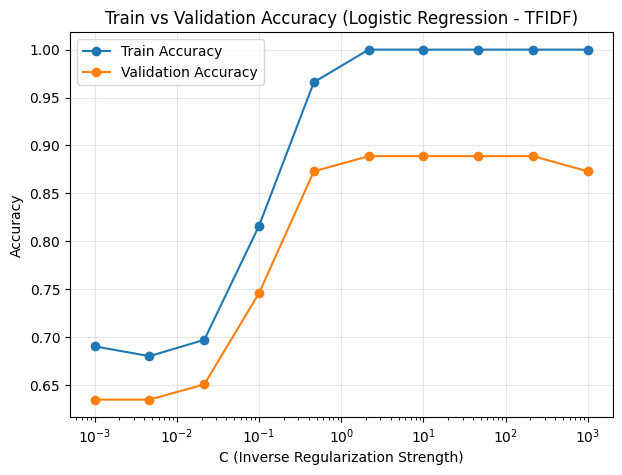

['/content/drive/MyDrive/Colab Notebooks/NLP Project/knowledge_representation/LR_tfidf.pkl']

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import validation_curve

# 1. Train model
lr_tf = LogisticRegression(
    C=1.0,
    max_iter=5000,
    solver="saga",
    penalty="l2"
)

lr_tf.fit(X_train_tf, y_train)

# 2. Predict
y_pred_tf = lr_tf.predict(X_test_tf)

# 3. Metrics
print("--- TF-IDF Logistic Regression ---")
print("Accuracy:", accuracy_score(y_test, y_pred_tf))
print("Train accuracy:", lr_tf.score(X_train_tf, y_train))
print("Test accuracy:", lr_tf.score(X_test_tf, y_test))

print("\nPrediction distribution:", np.bincount(y_pred_tf))
print("True distribution:", np.bincount(y_test))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_tf,
    target_names=le.classes_,
    zero_division=0
))

# 4. Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(
    confusion_matrix(y_test, y_pred_tf),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Confusion Matrix (TF-IDF Logistic Regression)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

C_values = np.logspace(-3, 3, 10)

train_acc = []
val_acc = []

for C in C_values:
    model = LogisticRegression(
    C=C,
    max_iter=5000,
    solver="saga",
    penalty="l2"
)

    model.fit(X_train_tf, y_train)

    train_acc.append(model.score(X_train_tf, y_train))
    val_acc.append(model.score(X_val_tf, y_val))

# plot
plt.figure(figsize=(7,5))

plt.plot(C_values, train_acc, marker='o', label="Train Accuracy")
plt.plot(C_values, val_acc, marker='o', label="Validation Accuracy")

plt.xscale("log")
plt.xlabel("C (Inverse Regularization Strength)")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy (Logistic Regression - TFIDF)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 6. Save model
joblib.dump(lr_tf, os.path.join(KR_DIR, "LR_tfidf.pkl"))

### Linear SVM (TF-IDF)

--- TF-IDF Linear SVM ---
Accuracy: 0.8253968253968254
Train accuracy: 1.0
Test accuracy: 0.8253968253968254

Prediction distribution: [24 14 25]
True distribution: [23 18 22]

Classification Report:
              precision    recall  f1-score   support

    negative       0.83      0.87      0.85        23
     neutral       0.86      0.67      0.75        18
    positive       0.80      0.91      0.85        22

    accuracy                           0.83        63
   macro avg       0.83      0.82      0.82        63
weighted avg       0.83      0.83      0.82        63



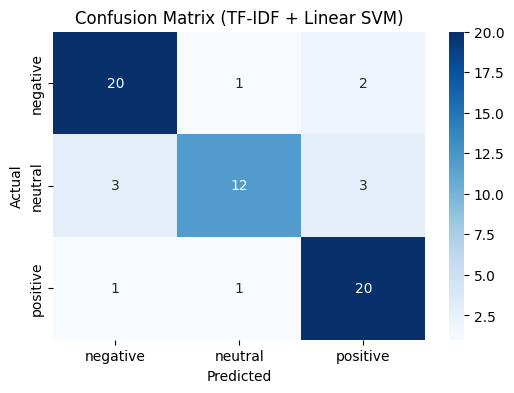

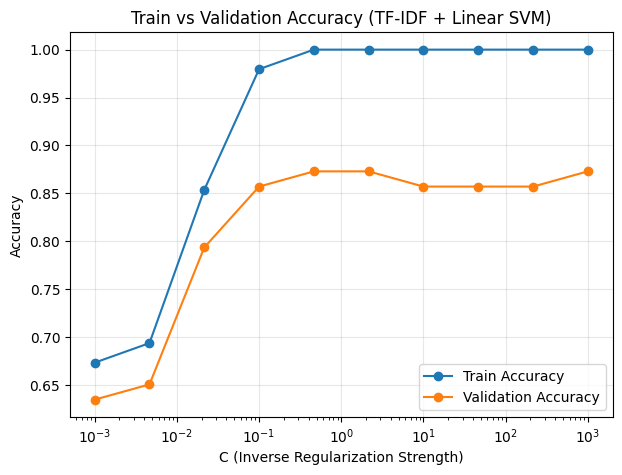

['/content/drive/MyDrive/Colab Notebooks/NLP Project/knowledge_representation/SVM_tfidf.pkl']

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Train model
svm_tf = LinearSVC(C=1.0, max_iter=5000)

svm_tf.fit(X_train_tf, y_train)

# 2. Predict
y_pred_svm = svm_tf.predict(X_test_tf)

# 3. Metrics
print("--- TF-IDF Linear SVM ---")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Train accuracy:", svm_tf.score(X_train_tf, y_train))
print("Test accuracy:", svm_tf.score(X_test_tf, y_test))

print("\nPrediction distribution:", np.bincount(y_pred_svm))
print("True distribution:", np.bincount(y_test))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_svm,
    target_names=le.classes_,
    zero_division=0
))

# 4. Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(
    confusion_matrix(y_test, y_pred_svm),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Confusion Matrix (TF-IDF + Linear SVM)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

C_values = np.logspace(-3, 3, 10)

train_acc = []
val_acc = []

for C in C_values:
    model = LinearSVC(C=C, max_iter=5000)

    model.fit(X_train_tf, y_train)

    train_acc.append(model.score(X_train_tf, y_train))
    val_acc.append(model.score(X_val_tf, y_val))

plt.figure(figsize=(7,5))

plt.plot(C_values, train_acc, marker='o', label="Train Accuracy")
plt.plot(C_values, val_acc, marker='o', label="Validation Accuracy")

plt.xscale("log")
plt.xlabel("C (Inverse Regularization Strength)")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy (TF-IDF + Linear SVM)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. Save model
joblib.dump(svm_tf, os.path.join(KR_DIR, "SVM_tfidf.pkl"))

### Random Forest (TF-IDF)

--- TF-IDF Random Forest ---
Accuracy: 0.7777777777777778
Train accuracy: 0.9693877551020408
Test accuracy: 0.7777777777777778

Prediction distribution: [24 13 26]
True distribution: [23 18 22]

Classification Report:
              precision    recall  f1-score   support

    negative       0.79      0.83      0.81        23
     neutral       0.69      0.50      0.58        18
    positive       0.81      0.95      0.88        22

    accuracy                           0.78        63
   macro avg       0.76      0.76      0.75        63
weighted avg       0.77      0.78      0.77        63



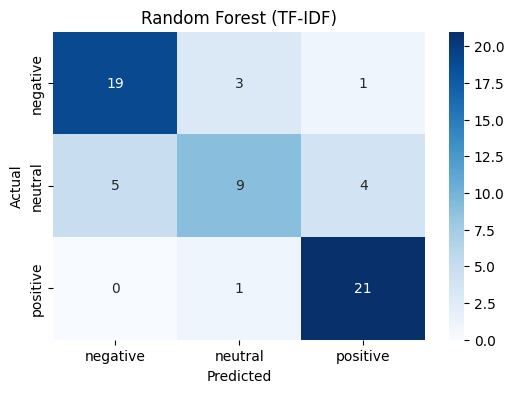

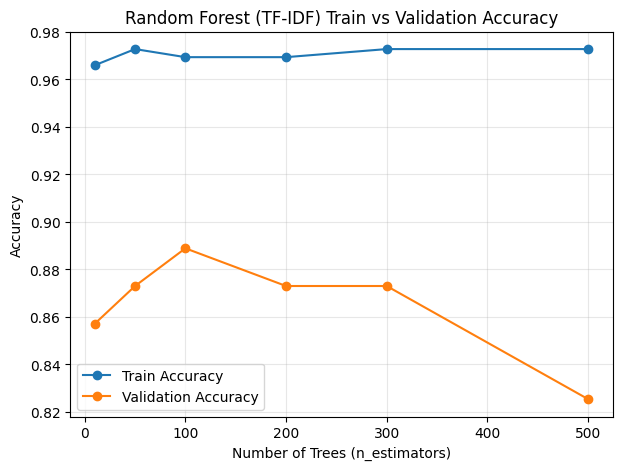

['/content/drive/MyDrive/Colab Notebooks/NLP Project/knowledge_representation/RF_tfidf.pkl']

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Train model
rf_tf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)

rf_tf.fit(X_train_tf, y_train)

# 2. Predict
y_pred_rf_tf = rf_tf.predict(X_test_tf)

# 3. Metrics
print("--- TF-IDF Random Forest ---")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_tf))
print("Train accuracy:", rf_tf.score(X_train_tf, y_train))
print("Test accuracy:", rf_tf.score(X_test_tf, y_test))

print("\nPrediction distribution:", np.bincount(y_pred_rf_tf))
print("True distribution:", np.bincount(y_test))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_rf_tf,
    target_names=le.classes_,
    zero_division=0
))

# 4. Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(
    confusion_matrix(y_test, y_pred_rf_tf),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Random Forest (TF-IDF)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

n_trees = [10, 50, 100, 200, 300, 500]

train_acc = []
val_acc = []

for n in n_trees:
    model = RandomForestClassifier(
        n_estimators=n,
        max_depth=20,
        min_samples_split=10,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_tf, y_train)

    train_acc.append(model.score(X_train_tf, y_train))
    val_acc.append(model.score(X_val_tf, y_val))

plt.figure(figsize=(7,5))

plt.plot(n_trees, train_acc, marker='o', label="Train Accuracy")
plt.plot(n_trees, val_acc, marker='o', label="Validation Accuracy")

plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Accuracy")
plt.title("Random Forest (TF-IDF) Train vs Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. Save model
joblib.dump(rf_tf, os.path.join(KR_DIR, "RF_tfidf.pkl"))

Among the traditional models, TF-IDF with Linear SVM achieved the highest test accuracy of 82.54%. RoBERTa achieved the highest overall accuracy of 88.89%.

### Naives Bayes (Word2Vec)

,Var Smoothing,Train Accuracy,Validation Accuracy,Validation Macro F1
0,1.000000e-12,0.836735,0.698413,0.648492
1,1.000000e-11,0.836735,0.698413,0.648492
2,1.000000e-10,0.836735,0.698413,0.648492
3,1.000000e-09,0.836735,0.698413,0.648492
4,1.000000e-08,0.836735,0.698413,0.648492
5,1.000000e-07,0.836735,0.698413,0.648492
6,1.000000e-06,0.836735,0.698413,0.648492


Best var_smoothing: 1e-12
Best Validation Macro F1: 0.6484920634920636

--- Word2Vec Gaussian Naive Bayes ---
Test Accuracy: 0.6190476190476191
Test Macro F1: 0.5925731658750278

Classification Report:
              precision    recall  f1-score   support

    negative       0.88      0.30      0.45        23
     neutral       0.52      0.67      0.59        18
    positive       0.62      0.91      0.74        22

    accuracy                           0.62        63
   macro avg       0.67      0.63      0.59        63
weighted avg       0.69      0.62      0.59        63



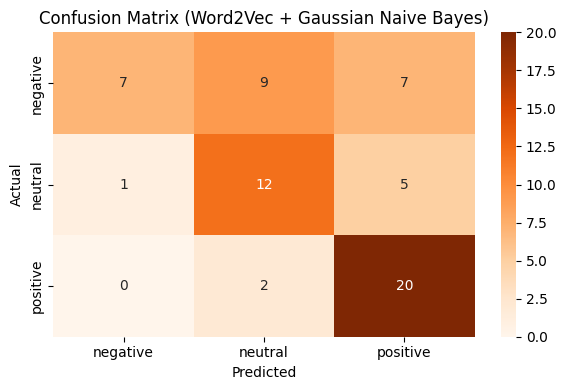

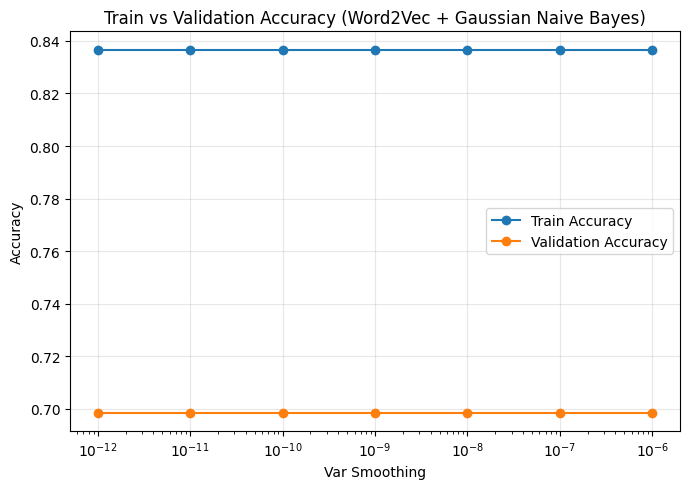

Word2Vec Gaussian Naive Bayes model saved successfully.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)


# -------------------------------------------------
# 1. Select var_smoothing using validation data
# -------------------------------------------------

smoothing_values = np.logspace(-12, -6, 7)

train_accuracy = []
validation_accuracy = []
validation_macro_f1 = []

for smoothing in smoothing_values:

    model = GaussianNB(
        var_smoothing=smoothing
    )

    model.fit(
        X_train_wv,
        y_train
    )

    train_prediction = model.predict(
        X_train_wv
    )

    validation_prediction = model.predict(
        X_val_wv
    )

    train_accuracy.append(
        accuracy_score(
            y_train,
            train_prediction
        )
    )

    validation_accuracy.append(
        accuracy_score(
            y_val,
            validation_prediction
        )
    )

    validation_macro_f1.append(
        f1_score(
            y_val,
            validation_prediction,
            average="macro"
        )
    )


# Show validation results
gnb_validation_results = pd.DataFrame({
    "Var Smoothing": smoothing_values,
    "Train Accuracy": train_accuracy,
    "Validation Accuracy": validation_accuracy,
    "Validation Macro F1": validation_macro_f1
})

display(gnb_validation_results)


# Select the best value using validation Macro F1
best_index = np.argmax(
    validation_macro_f1
)

best_smoothing = smoothing_values[
    best_index
]

print(
    "Best var_smoothing:",
    best_smoothing
)

print(
    "Best Validation Macro F1:",
    validation_macro_f1[best_index]
)


# -------------------------------------------------
# 2. Train selected model
# -------------------------------------------------

gnb_wv = GaussianNB(
    var_smoothing=best_smoothing
)

gnb_wv.fit(
    X_train_wv,
    y_train
)


# -------------------------------------------------
# 3. Final test prediction
# -------------------------------------------------

y_pred_gnb_wv = gnb_wv.predict(
    X_test_wv
)

print(
    "\n--- Word2Vec Gaussian Naive Bayes ---"
)

print(
    "Test Accuracy:",
    accuracy_score(
        y_test,
        y_pred_gnb_wv
    )
)

print(
    "Test Macro F1:",
    f1_score(
        y_test,
        y_pred_gnb_wv,
        average="macro"
    )
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_gnb_wv,
        target_names=le.classes_,
        zero_division=0
    )
)


# -------------------------------------------------
# 4. Confusion matrix
# -------------------------------------------------

plt.figure(figsize=(6, 4))

sns.heatmap(
    confusion_matrix(
        y_test,
        y_pred_gnb_wv
    ),
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title(
    "Confusion Matrix "
    "(Word2Vec + Gaussian Naive Bayes)"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


# -------------------------------------------------
# 5. Train vs validation graph
# -------------------------------------------------

plt.figure(figsize=(7, 5))

plt.plot(
    smoothing_values,
    train_accuracy,
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    smoothing_values,
    validation_accuracy,
    marker="o",
    label="Validation Accuracy"
)

plt.xscale("log")
plt.xlabel("Var Smoothing")
plt.ylabel("Accuracy")

plt.title(
    "Train vs Validation Accuracy "
    "(Word2Vec + Gaussian Naive Bayes)"
)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# -------------------------------------------------
# 6. Save model
# -------------------------------------------------

joblib.dump(
    gnb_wv,
    os.path.join(
        KR_DIR,
        "GaussianNB_w2v.pkl"
    )
)

print(
    "Word2Vec Gaussian Naive Bayes "
    "model saved successfully."
)

### Logistic Regression (Word2Vec)

--- Word2Vec Logistic Regression ---
Accuracy: 0.7142857142857143
Train accuracy: 0.8639455782312925
Test accuracy: 0.7142857142857143

Prediction distribution: [22 15 26]
True distribution: [23 18 22]

Classification Report:
              precision    recall  f1-score   support

    negative       0.77      0.74      0.76        23
     neutral       0.60      0.50      0.55        18
    positive       0.73      0.86      0.79        22

    accuracy                           0.71        63
   macro avg       0.70      0.70      0.70        63
weighted avg       0.71      0.71      0.71        63



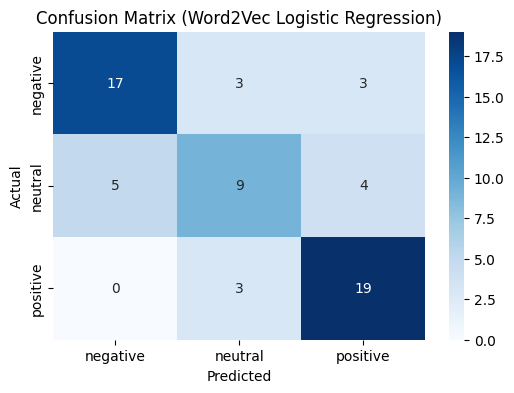

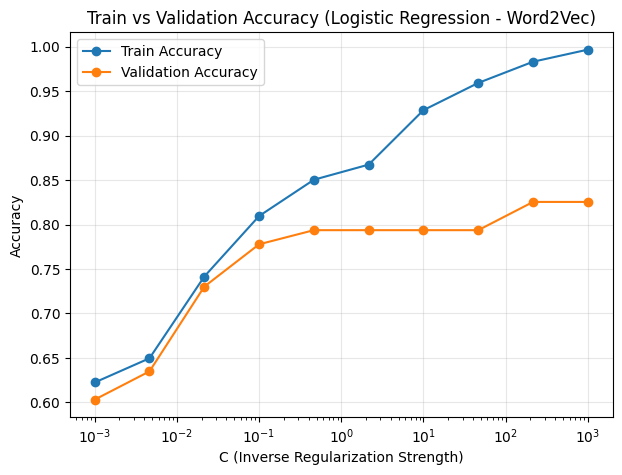

['/content/drive/MyDrive/Colab Notebooks/NLP Project/knowledge_representation/LR_w2v.pkl']

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import validation_curve

# 1. Train model
lr_tf = LogisticRegression(
    C=1.0,
    max_iter=5000,
    solver="liblinear",
    penalty="l2"
)

lr_tf.fit(X_train_wv, y_train)

# 2. Predict
y_pred_wv = lr_tf.predict(X_test_wv)

# 3. Metrics
print("--- Word2Vec Logistic Regression ---")
print("Accuracy:", accuracy_score(y_test, y_pred_wv))
print("Train accuracy:", lr_tf.score(X_train_wv, y_train))
print("Test accuracy:", lr_tf.score(X_test_wv, y_test))

print("\nPrediction distribution:", np.bincount(y_pred_wv))
print("True distribution:", np.bincount(y_test))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_wv,
    target_names=le.classes_,
    zero_division=0
))

# 4. Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(
    confusion_matrix(y_test, y_pred_wv),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Confusion Matrix (Word2Vec Logistic Regression)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

C_values = np.logspace(-3, 3, 10)

train_acc = []
val_acc = []

for C in C_values:
    model = LogisticRegression(
    C=C,
    max_iter=5000,
    solver="liblinear",
    penalty="l2"
)

    model.fit(X_train_wv, y_train)

    train_acc.append(model.score(X_train_wv, y_train))
    val_acc.append(model.score(X_val_wv, y_val))

# plot
plt.figure(figsize=(7,5))

plt.plot(C_values, train_acc, marker='o', label="Train Accuracy")
plt.plot(C_values, val_acc, marker='o', label="Validation Accuracy")

plt.xscale("log")
plt.xlabel("C (Inverse Regularization Strength)")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy (Logistic Regression - Word2Vec)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 6. Save model
joblib.dump(lr_tf, os.path.join(KR_DIR, "LR_w2v.pkl"))

### Linear SVM (Word2Vec)

--- Word2Vec Linear SVM ---
Accuracy: 0.746031746031746
Train accuracy: 0.9319727891156463
Test accuracy: 0.746031746031746

Prediction distribution: [23 14 26]
True distribution: [23 18 22]

Classification Report:
              precision    recall  f1-score   support

    negative       0.83      0.83      0.83        23
     neutral       0.64      0.50      0.56        18
    positive       0.73      0.86      0.79        22

    accuracy                           0.75        63
   macro avg       0.73      0.73      0.73        63
weighted avg       0.74      0.75      0.74        63



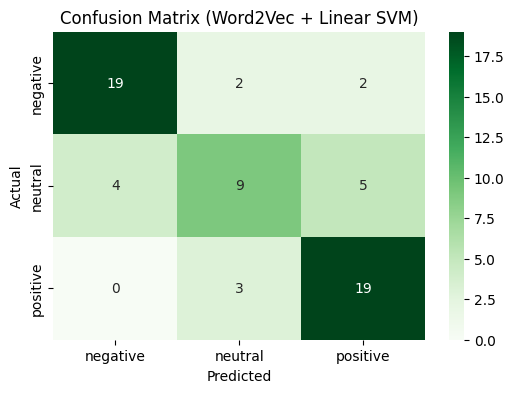

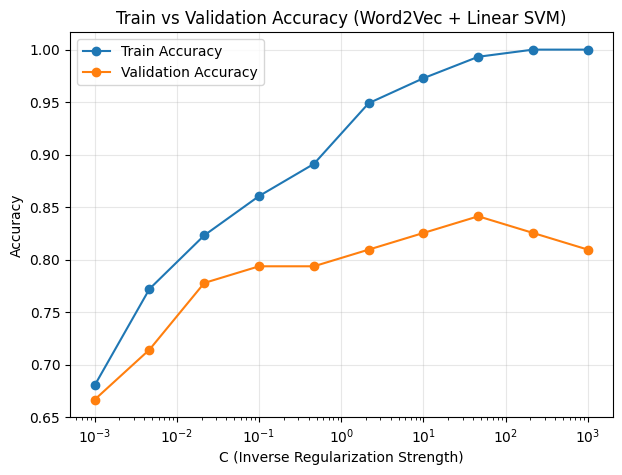

['/content/drive/MyDrive/Colab Notebooks/NLP Project/knowledge_representation/SVM_w2v.pkl']

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Train model
svm_w2v = LinearSVC(C=1.0, max_iter=5000)

svm_w2v.fit(X_train_wv, y_train)

# 2. Predict
y_pred_svm_wv = svm_w2v.predict(X_test_wv)

# 3. Metrics
print("--- Word2Vec Linear SVM ---")
print("Accuracy:", accuracy_score(y_test, y_pred_svm_wv))
print("Train accuracy:", svm_w2v.score(X_train_wv, y_train))
print("Test accuracy:", svm_w2v.score(X_test_wv, y_test))

print("\nPrediction distribution:", np.bincount(y_pred_svm_wv))
print("True distribution:", np.bincount(y_test))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_svm_wv,
    target_names=le.classes_,
    zero_division=0
))

# 4. Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(
    confusion_matrix(y_test, y_pred_svm_wv),
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Confusion Matrix (Word2Vec + Linear SVM)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

C_values = np.logspace(-3, 3, 10)

train_acc = []
val_acc = []

for C in C_values:
    model = LinearSVC(C=C, max_iter=5000)

    model.fit(X_train_wv, y_train)

    train_acc.append(model.score(X_train_wv, y_train))
    val_acc.append(model.score(X_val_wv, y_val))

plt.figure(figsize=(7,5))

plt.plot(C_values, train_acc, marker='o', label="Train Accuracy")
plt.plot(C_values, val_acc, marker='o', label="Validation Accuracy")

plt.xscale("log")
plt.xlabel("C (Inverse Regularization Strength)")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy (Word2Vec + Linear SVM)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. Save model
joblib.dump(svm_w2v, os.path.join(KR_DIR, "SVM_w2v.pkl"))

### Random Forest (Word2Vec)

--- Word2Vec Random Forest ---
Accuracy: 0.6666666666666666
Train accuracy: 1.0
Test accuracy: 0.6666666666666666

Prediction distribution: [16 18 29]
True distribution: [23 18 22]

Classification Report:
              precision    recall  f1-score   support

    negative       0.81      0.57      0.67        23
     neutral       0.56      0.56      0.56        18
    positive       0.66      0.86      0.75        22

    accuracy                           0.67        63
   macro avg       0.67      0.66      0.66        63
weighted avg       0.68      0.67      0.66        63



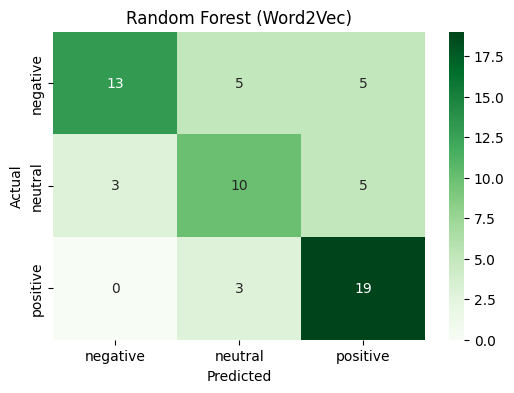

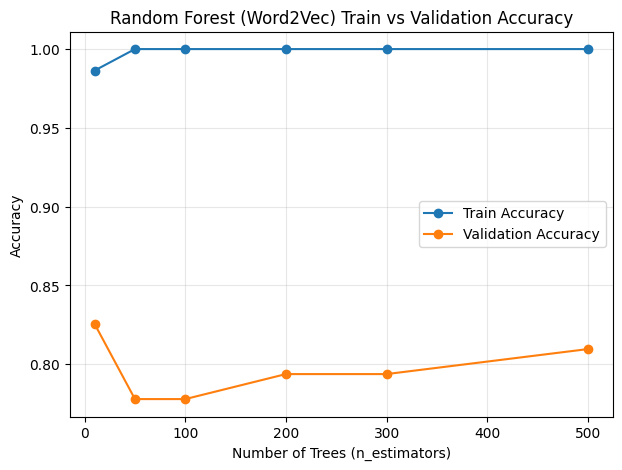

['/content/drive/MyDrive/Colab Notebooks/NLP Project/knowledge_representation/RF_w2v.pkl']

In [ ]:
rf_wv = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_wv.fit(X_train_wv, y_train)

y_pred_rf_wv = rf_wv.predict(X_test_wv)

print("--- Word2Vec Random Forest ---")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_wv))
print("Train accuracy:", rf_wv.score(X_train_wv, y_train))
print("Test accuracy:", rf_wv.score(X_test_wv, y_test))

print("\nPrediction distribution:", np.bincount(y_pred_rf_wv))
print("True distribution:", np.bincount(y_test))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_rf_wv,
    target_names=le.classes_,
    zero_division=0
))

plt.figure(figsize=(6,4))
sns.heatmap(
    confusion_matrix(y_test, y_pred_rf_wv),
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Random Forest (Word2Vec)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

n_trees = [10, 50, 100, 200, 300, 500]

train_acc = []
val_acc = []

for n in n_trees:
    model = RandomForestClassifier(
        n_estimators=n,
        max_depth=20,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_wv, y_train)

    train_acc.append(model.score(X_train_wv, y_train))
    val_acc.append(model.score(X_val_wv, y_val))

plt.figure(figsize=(7,5))

plt.plot(n_trees, train_acc, marker='o', label="Train Accuracy")
plt.plot(n_trees, val_acc, marker='o', label="Validation Accuracy")

plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Accuracy")
plt.title("Random Forest (Word2Vec) Train vs Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

joblib.dump(rf_wv, os.path.join(KR_DIR, "RF_w2v.pkl"))

# **Advance Feature**

In [ ]:
!pip install transformers datasets evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.7 MB/s eta 0:00:00


## Transformer: BERT

--- Initializing Model: bert-base-uncased ---


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte


--- Generating Predictions ---



bert-base-uncased Detailed Metrics:
Accuracy: 0.7460

--- Classification Report ---
              precision    recall  f1-score   support

    negative       0.84      0.70      0.76        23
     neutral       0.69      0.61      0.65        18
    positive       0.71      0.91      0.80        22

    accuracy                           0.75        63
   macro avg       0.75      0.74      0.74        63
weighted avg       0.75      0.75      0.74        63



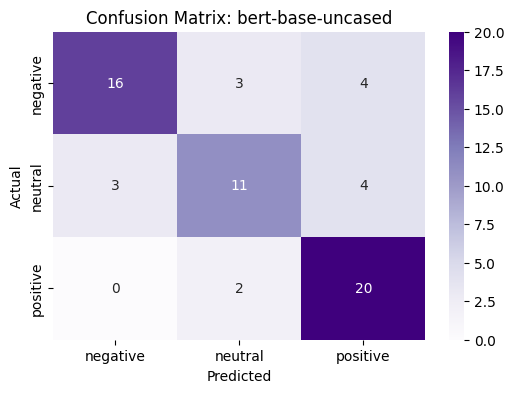

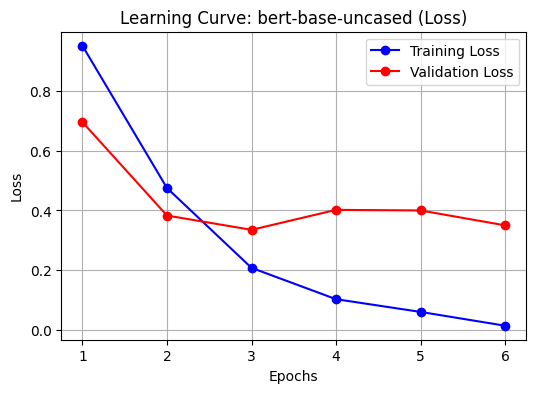

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/Colab Notebooks/NLP Project/knowledge_representation/bert-base-uncased_best_model/tokenizer_config.json',
 '/content/drive/MyDrive/Colab Notebooks/NLP Project/knowledge_representation/bert-base-uncased_best_model/tokenizer.json')

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Define the Model
MODEL_NAME = "bert-base-uncased"
print(f"--- Initializing Model: {MODEL_NAME} ---")

le = LabelEncoder()
y = le.fit_transform(reviews['Class'])

# 2. Reuse the shared train, validation, and test split
y_train_hf = le.transform(train_df['Class'])
y_val_hf = le.transform(validation_df['Class'])
y_test_hf = le.transform(test_df['Class'])

train_ds = Dataset.from_dict({
    'text': train_df['translated'].tolist(),
    'label': y_train_hf
})
val_ds = Dataset.from_dict({
    'text': validation_df['translated'].tolist(),
    'label': y_val_hf
})
test_ds = Dataset.from_dict({
    'text': test_df['translated'].tolist(),
    'label': y_test_hf
})

# 3. Tokenization

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_func(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

train_tokenized = train_ds.map(tokenize_func, batched=True)
val_tokenized = val_ds.map(tokenize_func, batched=True)
test_tokenized = test_ds.map(tokenize_func, batched=True)

# 4. Initialize Model
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)

for param in model.bert.embeddings.parameters():
    param.requires_grad = False

for layer in model.bert.encoder.layer[:8]:
    for param in layer.parameters():
        param.requires_grad = False

# 5. Training Arguments
training_args = TrainingArguments(
    output_dir=f"./results_{MODEL_NAME}",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=16,
    num_train_epochs=20,
    weight_decay=0.2,
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    greater_is_better=False,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

# 6. Train the Model
print("Starting training...")
trainer.train()

# 7. Predictions & Metrics
print("\n--- Generating Predictions ---")
predictions_output = trainer.predict(test_tokenized)
y_pred_hf = np.argmax(predictions_output.predictions, axis=-1)

print(f"\n{MODEL_NAME} Detailed Metrics:")
print(f"Accuracy: {accuracy_score(y_test_hf, y_pred_hf):.4f}")
print("\n--- Classification Report ---")
print(classification_report(y_test_hf, y_pred_hf, target_names=le.classes_))

# 8. Visual Diagnosis: Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test_hf, y_pred_hf), annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f"Confusion Matrix: {MODEL_NAME}")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()

# 9. Visual Diagnosis: Learning Curve (Overfitting Check)
# Extract training and validation loss from trainer logs
history = trainer.state.log_history
train_loss = [x['loss'] for x in history if 'loss' in x]
eval_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]

if train_loss and eval_loss:
    plt.figure(figsize=(6, 4))
    # Adjust x-axis depending on logging steps, simple alignment for epochs
    epochs = range(1, len(eval_loss) + 1)
    # We take the last few train_loss entries that correspond to epoch ends
    aligned_train_loss = train_loss[-len(eval_loss):]

    plt.plot(epochs, aligned_train_loss, label='Training Loss', marker='o', color='blue')
    plt.plot(epochs, eval_loss, label='Validation Loss', marker='o', color='red')
    plt.title(f"Learning Curve: {MODEL_NAME} (Loss)")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

# 10. Save the final model
trainer.save_model(os.path.join(KR_DIR, f"{MODEL_NAME}_best_model"))
tokenizer.save_pretrained(os.path.join(KR_DIR, f"{MODEL_NAME}_best_model"))

## Transformer: DistilBERT


--- Initializing Model: distilbert-base-uncased ---


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


--- Generating Predictions ---



distilbert-base-uncased Detailed Metrics:
Accuracy: 0.8413

--- Classification Report ---
              precision    recall  f1-score   support

    negative       0.95      0.87      0.91        23
     neutral       0.71      0.83      0.77        18
    positive       0.86      0.82      0.84        22

    accuracy                           0.84        63
   macro avg       0.84      0.84      0.84        63
weighted avg       0.85      0.84      0.84        63



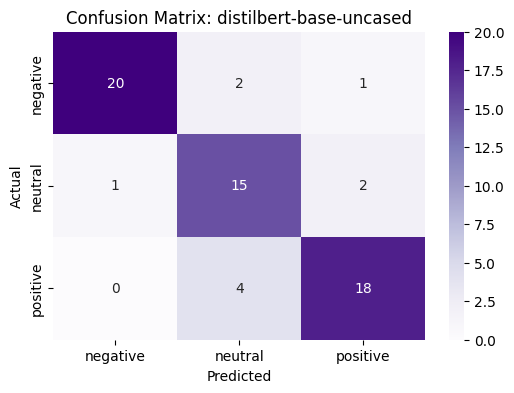

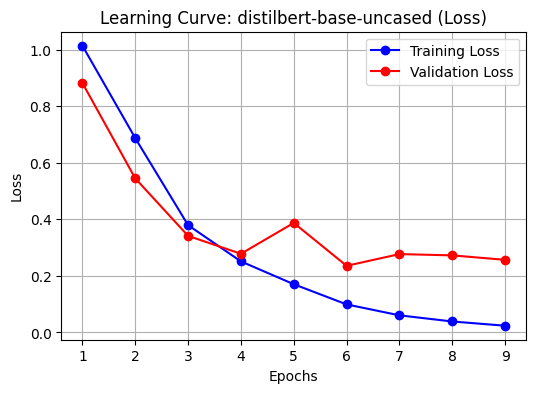

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/Colab Notebooks/NLP Project/knowledge_representation/distilbert-base-uncased_best_model/tokenizer_config.json',
 '/content/drive/MyDrive/Colab Notebooks/NLP Project/knowledge_representation/distilbert-base-uncased_best_model/tokenizer.json')

In [ ]:
# ==========================================
# Transformer: DistilBERT
# ==========================================
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Define the Model
MODEL_NAME = "distilbert-base-uncased"
print(f"--- Initializing Model: {MODEL_NAME} ---")

le = LabelEncoder()
y = le.fit_transform(reviews['Class'])

# 2. Reuse the shared train, validation, and test split
y_train_hf = le.transform(train_df['Class'])
y_val_hf = le.transform(validation_df['Class'])
y_test_hf = le.transform(test_df['Class'])

train_ds = Dataset.from_dict({
    'text': train_df['translated'].tolist(),
    'label': y_train_hf
})
val_ds = Dataset.from_dict({
    'text': validation_df['translated'].tolist(),
    'label': y_val_hf
})
test_ds = Dataset.from_dict({
    'text': test_df['translated'].tolist(),
    'label': y_test_hf
})

# 3. Tokenization

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_func(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

train_tokenized = train_ds.map(tokenize_func, batched=True)
val_tokenized = val_ds.map(tokenize_func, batched=True)
test_tokenized = test_ds.map(tokenize_func, batched=True)

# 4. Initialize Model
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)

for param in model.distilbert.embeddings.parameters():
    param.requires_grad = False

for layer in model.distilbert.transformer.layer[:4]:
    for param in layer.parameters():
        param.requires_grad = False

# 5. Training Arguments
training_args = TrainingArguments(
    output_dir=f"./results_{MODEL_NAME}",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=16,
    num_train_epochs=20,
    weight_decay=0.2,
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    greater_is_better=False,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

# 6. Train the Model
print("Starting training...")
trainer.train()

# 7. Predictions & Metrics
print("\n--- Generating Predictions ---")
predictions_output = trainer.predict(test_tokenized)
y_pred_hf = np.argmax(predictions_output.predictions, axis=-1)

print(f"\n{MODEL_NAME} Detailed Metrics:")
print(f"Accuracy: {accuracy_score(y_test_hf, y_pred_hf):.4f}")
print("\n--- Classification Report ---")
print(classification_report(y_test_hf, y_pred_hf, target_names=le.classes_))

# 8. Visual Diagnosis: Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test_hf, y_pred_hf), annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f"Confusion Matrix: {MODEL_NAME}")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()

# 9. Visual Diagnosis: Learning Curve (Overfitting Check)
# Extract training and validation loss from trainer logs
history = trainer.state.log_history
train_loss = [x['loss'] for x in history if 'loss' in x]
eval_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]

if train_loss and eval_loss:
    plt.figure(figsize=(6, 4))
    # Adjust x-axis depending on logging steps, simple alignment for epochs
    epochs = range(1, len(eval_loss) + 1)
    # We take the last few train_loss entries that correspond to epoch ends
    aligned_train_loss = train_loss[-len(eval_loss):]

    plt.plot(epochs, aligned_train_loss, label='Training Loss', marker='o', color='blue')
    plt.plot(epochs, eval_loss, label='Validation Loss', marker='o', color='red')
    plt.title(f"Learning Curve: {MODEL_NAME} (Loss)")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

# 10. Save the final model
trainer.save_model(os.path.join(KR_DIR, f"{MODEL_NAME}_best_model"))
tokenizer.save_pretrained(os.path.join(KR_DIR, f"{MODEL_NAME}_best_model"))

## Transformer: RoBERTa

In [2]:
# ==========================================
# Transformer: RoBERTa
# ==========================================
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from deep_translator import GoogleTranslator

def translate_to_english(text):
    try:
        translated = GoogleTranslator(
            source="auto",
            target="en"
        ).translate(text)

        return translated if translated else text

    except Exception as e:
        print("Translation failed:", e)
        return text

# 1. Define the Model
MODEL_NAME = "roberta-base"
print(f"--- Initializing Model: {MODEL_NAME} ---")

le = LabelEncoder()
y = le.fit_transform(reviews['Class'])

# 2. Reuse the shared train, validation, and test split
y_train_hf = le.transform(train_df['Class'])
y_val_hf = le.transform(validation_df['Class'])
y_test_hf = le.transform(test_df['Class'])

train_ds = Dataset.from_dict({
    'text': train_df['translated'].tolist(),
    'label': y_train_hf
})
val_ds = Dataset.from_dict({
    'text': validation_df['translated'].tolist(),
    'label': y_val_hf
})
test_ds = Dataset.from_dict({
    'text': test_df['translated'].tolist(),
    'label': y_test_hf
})

# 3. Tokenization

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_func(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

train_tokenized = train_ds.map(tokenize_func, batched=True)
val_tokenized = val_ds.map(tokenize_func, batched=True)
test_tokenized = test_ds.map(tokenize_func, batched=True)

# 4. Initialize Model
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)

for param in model.roberta.embeddings.parameters():
    param.requires_grad = False
for layer in model.roberta.encoder.layer[:8]:
    for param in layer.parameters():
        param.requires_grad = False

# 5. Training Arguments
training_args = TrainingArguments(
    output_dir=f"./results_{MODEL_NAME}",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=16,
    num_train_epochs=20,
    weight_decay=0.2,
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    greater_is_better=False,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

# 6. Train the Model
trainer.train()

# 7. Predictions & Metrics
predictions_output = trainer.predict(test_tokenized)
y_pred_hf = np.argmax(predictions_output.predictions, axis=-1)

print(f"Accuracy: {accuracy_score(y_test_hf, y_pred_hf):.4f}")
print("\n--- Classification Report ---")
print(classification_report(y_test_hf, y_pred_hf, target_names=le.classes_))

# 8. Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test_hf, y_pred_hf), annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f"Confusion Matrix: {MODEL_NAME}")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()

# 9. Learning Curve
history = trainer.state.log_history
train_loss = [x['loss'] for x in history if 'loss' in x]
eval_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]

if train_loss and eval_loss:
    plt.figure(figsize=(6, 4))
    epochs = range(1, len(eval_loss) + 1)
    aligned_train_loss = train_loss[-len(eval_loss):]

    plt.plot(epochs, aligned_train_loss, label='Training Loss', marker='o', color='blue')
    plt.plot(epochs, eval_loss, label='Validation Loss', marker='o', color='red')
    plt.title(f"Learning Curve: {MODEL_NAME} (Loss)")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

# 10. Save the final model
trainer.save_model(os.path.join(KR_DIR, f"{MODEL_NAME}_best_model"))
tokenizer.save_pretrained(os.path.join(KR_DIR, f"{MODEL_NAME}_best_model"))

--- Initializing Model: roberta-base ---


NameError: name 'reviews' is not defined

In [ ]:
import os
import joblib
import numpy as np
import re
import gradio as gr
import torch
import socket
import subprocess
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# ============================================================================
# CONFIG
# ============================================================================

KR_DIR = '/content/drive/MyDrive/Colab Notebooks/NLP Project/knowledge_representation'
MODEL_PATH = os.path.join(KR_DIR, 'roberta-base_best_model')

# ============================================================================
# LABEL ENCODER
# ============================================================================

le_path = os.path.join(KR_DIR, 'label_encoder.pkl')

if os.path.exists(le_path):
    label_encoder = joblib.load(le_path)
else:
    from sklearn.preprocessing import LabelEncoder
    label_encoder = LabelEncoder()
    label_encoder.classes_ = np.array(['negative', 'neutral', 'positive'])

# ============================================================================
# LOAD MODEL
# ============================================================================

print("Loading RoBERTa model...")

roberta_loaded = False

try:
    tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, local_files_only=True)
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH, local_files_only=True)
    model.eval()
    roberta_loaded = True
    print("✓ RoBERTa loaded successfully")
except Exception as e:
    print(f"❌ Failed to load RoBERTa: {e}")

# ============================================================================
# PREPROCESSING
# ============================================================================

def preprocess_text(text):
    if not text:
        return ""

    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'\d+', '', text)
    #text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# ============================================================================
# PREDICTION
# ============================================================================

def predict_sentiment(text):
    if not text or text.strip() == "":
        return "⚠️ Please enter a review", ""

    if not roberta_loaded:
        return "❌ Model not loaded", ""

    model_text = translate_to_english(text.strip())

    inputs = tokenizer(
        model_text,
        padding="max_length",
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1).numpy()[0]

    pred = int(np.argmax(probs))
    sentiment = label_encoder.inverse_transform([pred])[0]
    confidence = float(probs[pred] * 100)

    all_probs = {
        label: float(prob * 100)
        for label, prob in zip(label_encoder.classes_, probs)
    }

    emoji_map = {
        "positive": "😊",
        "neutral": "😐",
        "negative": "😞"
    }

    color_map = {
        "positive": "#22c55e",
        "neutral": "#eab308",
        "negative": "#ef4444"
    }

    emoji = emoji_map.get(sentiment, "")
    color = color_map.get(sentiment, "#333")

    html = f"""
    <div style="
        padding: 24px;
        border-radius: 16px;
        border: 2px solid {color};
        background: #f9fafb;
        text-align: center;
    ">
        <div style="font-size: 55px;">{emoji}</div>

        <div style="font-size: 26px; font-weight: 700; color: {color}; margin-top: 8px;">
            {sentiment.upper()}
        </div>

        <div style="margin-top: 8px; font-size: 15px;">
            Confidence: <b>{confidence:.2f}%</b>
        </div>

        <hr style="margin: 14px 0; border: 0; border-top: 1px solid #ddd;">

        <div style="text-align: left; font-size: 14px;">
            <div>😊 Positive: <b>{all_probs['positive']:.2f}%</b></div>
            <div>😐 Neutral: <b>{all_probs['neutral']:.2f}%</b></div>
            <div>😞 Negative: <b>{all_probs['negative']:.2f}%</b></div>
        </div>
    </div>
    """

    return html, f"{sentiment} ({confidence:.2f}%)"

# ============================================================================
# CSS
# ============================================================================

css = """
iframe{
  height: 420px;
}
footer.svelte-zxu34v {
  display: none;
}
.wrap.default.svelte-1uj8rng {
  display: none;
}
div.unequal-height.svelte-7xavid
{
  flex-wrap: nowrap;
}

b, h1, div{
  color: black;
}
.gradio-container {
    font-family: Arial;
    background: #f8fafc !important;
}

textarea {
    border-radius: 12px !important;
    padding: 12px !important;
    font-size: 15px !important;
}

button {
    background: #6366f1 !important;
    color: white !important;
    border-radius: 10px !important;
}
"""

# ============================================================================
# UI (60/40 SPLIT)
# ============================================================================

with gr.Blocks(title="RoBERTa Sentiment Analysis", css=css) as iface:

    gr.Markdown("""
    # 🎯 RoBERTa Sentiment Analysis
    """)

    with gr.Row():

        # ================= LEFT (60%) =================
        with gr.Column(scale=6):
            input_text = gr.Textbox(
                label="Your Review",
                placeholder="Type your review here...",
                lines=10
            )

            btn = gr.Button("Analyze Sentiment")

        # ================= RIGHT (40%) =================
        with gr.Column(scale=4):
            output_html = gr.HTML(
                value="""
                <div style="
                    padding: 30px;
                    text-align: center;
                    color: #999;
                    background: white;
                    border-radius: 16px;
                ">
                    Awaiting input...
                </div>
                """
            )

            summary = gr.Textbox(label="Summary")

    btn.click(
        predict_sentiment,
        inputs=input_text,
        outputs=[output_html, summary]
    )

    input_text.submit(
        predict_sentiment,
        inputs=input_text,
        outputs=[output_html, summary]
    )

# ============================================================================
# SAFE LAUNCH
# ============================================================================

def find_free_port():
    for port in range(7860, 7900):
        with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
            if s.connect_ex(("127.0.0.1", port)) != 0:
                return port
    return 7860

for p in range(7860, 7900):
    subprocess.run(["fuser", "-k", f"{p}/tcp"], capture_output=True)

port = find_free_port()

print(f"\n🚀 Launching on port: {port}")

if __name__ == "__main__":
    iface.launch(
        share=True,
        server_name="0.0.0.0",
        server_port=port,
        debug=False
    )

Loading RoBERTa model...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✓ RoBERTa loaded successfully


/tmp/ipykernel_7586/2506752540.py:188: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: css. Please pass these parameters to launch() instead.
  with gr.Blocks(title="RoBERTa Sentiment Analysis", css=css) as iface:
